In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from utils_analysis import *
import numpy as np
import seaborn as sb
from collections import Counter

In [2]:
prefix = "/infres/ir800/rapaport/results/FULL/focus/classes"
class_files = os.listdir(prefix)
alone, single, couple, triple = Counter(), Counter(), Counter(), Counter()
df = pd.DataFrame()
for file in class_files:
    df = pd.concat([df, pd.read_csv(prefix + "/" + file, delimiter=";")])
    #df = pd.read_csv(file, delimiter=";")

In [3]:
pattern = r"^refs/heads/(main|master|dev|devel|develop|development)$"
df = df.loc[df['branch_name'].apply(lambda x: re.search(pattern, x) is not None)]
stats = list(map(lambda categ: categ.strip("{}").split(", "), df["sub_categories"]))
out_of = add_relations_v2(alone, single, couple, triple, stats)
df

,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories
0,https://github.com/kohkimakimoto/xssh,swh:1:snp:65ff469dd22aeb071a75d563327468616484...,refs/heads/master,swh:1:rev:2868df901ea623114abea4cbfbfcfe190ccb...,swh:1:snp:cf9f639cf4b85143fb1b894c86d30e078029...,"Some(""swh:1:rev:2868df901ea623114abea4cbfbfcfe...",DIR,{DifferentBranchName}
1,https://github.com/krisp1/krisp1.github.io,swh:1:snp:f3e8381f70da6ecc4d114626d0f5def6806d...,refs/heads/master,swh:1:rev:485eed8fb5e62363c91b2cf316e891356b44...,swh:1:snp:b762ef168fd630747edc2fbbc5992a297a6a...,NaN,DIR,"{ContentModified, ContentRemoved}"
2,https://github.com/kyrogon/kyrogon.github.io,swh:1:snp:bbf31fc5c24511e3b1f278c2bd6c02daf300...,refs/heads/master,swh:1:rev:c31f2c35149fa444d8ac81e674048981b5d3...,swh:1:snp:89b505da7fbb21ce8483cac7ae79e3ba1cdc...,NaN,DIR,{ContentModified}
3,https://github.com/kzz710/kzz710.github.io,swh:1:snp:4a1e274c4f0d5963633dc70514d1f417524f...,refs/heads/master,swh:1:rev:0f3cc235c1813bef907b41c7931695757080...,swh:1:snp:1644a8746b384c7f6c0b7b8403671641fce1...,"Some(""swh:1:rev:edbfd32620710988987ff1e852b8b0...",META,"{Author, Committer, Date, CommitterDate}"
4,https://github.com/kofemann/linux-redpatch,swh:1:snp:0d6de0f9d91cb6cd430b466e8fc8f9055210...,refs/heads/master,swh:1:rev:78eb00cc574d3dbf8e6bed804948a89e8110...,swh:1:snp:a739e574b976565f0fccbe896041a0fcb34c...,"Some(""swh:1:rev:78eb00cc574d3dbf8e6bed804948a8...",DIR,{DifferentBranchName}
...,...,...,...,...,...,...,...,...
13849,https://github.com/djani2703/Algorithms,swh:1:snp:d244703caafe8fefe205c370101c55cb1537...,refs/heads/master,swh:1:rev:51acd79aa8227aea588ba99358767a47f711...,swh:1:snp:1ab9f65f0e11a5ceb1259a533e314560f417...,NaN,DIR,{ContentRemoved}
13850,https://github.com/dongnengyu/dongnengyu.githu...,swh:1:snp:ad27818dac12e27b942410052b4b2b8c840e...,refs/heads/master,swh:1:rev:c6c9a851c8513ac26c7be845347efd3b64a4...,swh:1:snp:d204d7610661f2ec37589142e7874fab68eb...,NaN,DIR,{ContentModified}
13851,https://github.com/dibsonmuad/acad,swh:1:snp:b4b9daa4d349b4a340ed9d863cd03b6df451...,refs/heads/master,swh:1:rev:8a1c752017d49c72f73912eccb1dbf501169...,swh:1:snp:5a4edbe02a9fca00f7980b7f3f9add3b4fef...,"Some(""swh:1:rev:47f5e1c9d5e64f2d8fa0ce6fc8a805...",META,{Committer}
13852,https://github.com/dnhansen/dnhansen.github.io,swh:1:snp:0779205db215cf4024a7c387aecf6f193ea9...,refs/heads/master,swh:1:rev:eedf56dcd710025fedaeddae589fc95af8ef...,swh:1:snp:7c83a150f9afadcb431c20405b9c0f5bd520...,NaN,DIR,{ContentRemoved}


In [4]:
len(df['origin'].drop_duplicates())

499276

In [5]:
size = len(df)
meta_size = len(df.loc[df['main_category'] == 'META'])
print("nb META: ", meta_size)
dir_size = len(df.loc[df['main_category'] == 'DIR'])
print("nb DIR: ", dir_size)
smt = size - meta_size - dir_size
smt2 = df.loc[(df['main_category'] != 'META') & (df['main_category'] != 'DIR')]
smt2

nb META:  142188
nb DIR:  547851


,origin,snapshot_src,branch_name,missing_commit,snapshot_dst,first_difference,main_category,sub_categories
7660,https://github.com/Daiver/jff,swh:1:snp:79e45326b8bff8f2a5f5851e21143629cdc3...,refs/heads/master,swh:1:rev:43634fc0eb5e4df125328b096325fa6a3b69...,swh:1:snp:f0d11befc08f065f388df195854a2c9245d3...,NaN,LoadingIssue,{}
11128,https://github.com/blerou/dotfiles,swh:1:snp:c2874015dbd8fd49880b000cf14367b8791a...,refs/heads/master,swh:1:rev:e066f803e2a6f38f34b07770038e19c5273c...,swh:1:snp:7fecf392a98c486b6ec3c8bad2ed336ac0f9...,NaN,LoadingIssue,{}
12693,https://github.com/kbhomes/kbhomes.github.com,swh:1:snp:a6ae8d0c85cf5c22c5a296ca2112a4ddbf6d...,refs/heads/master,swh:1:rev:391805e6fd6cc7478176bcf7c1259e6bd9dd...,swh:1:snp:d481f79fecd37a5e8213786566126edc556a...,NaN,LoadingIssue,{}
4059,https://github.com/neilguangzhou/neilguangzhou...,swh:1:snp:6878996706c517ffa354158332158474006b...,refs/heads/master,swh:1:rev:784ef55c03d4d9feac865159704565e92f88...,swh:1:snp:4fcad53008b30f1349f56341c109d69e9049...,NaN,LoadingIssue,{}
7135,https://github.com/tfrere/frameworkCss,swh:1:snp:b4e7f017abea8d55c9514668529cc3a657ad...,refs/heads/master,swh:1:rev:1ef43d77cad9f835c087c8c2cddf131c4458...,swh:1:snp:ffa60fbdabe77ea166827833849c9e5ca981...,NaN,LoadingIssue,{}
1005,https://github.com/cf020031308/cf020031308.git...,swh:1:snp:53543c96aed7d7a52f19fe7bce43ee3c0270...,refs/heads/master,swh:1:rev:3e77c4df1b1af75a61dcacfa126dd74ccd33...,swh:1:snp:da1eefde0ee127fb3e16021c91cf70c6b487...,NaN,LoadingIssue,{}
2968,https://github.com/HeroWit/HeroWit.github.io,swh:1:snp:8393acb4dea530619266631d4c0730629318...,refs/heads/master,swh:1:rev:61cd15f16fd4fc787df35b3c51b0d66d8fa7...,swh:1:snp:60416816d0b7b75f8335f70344efc0bec4a1...,NaN,LoadingIssue,{}


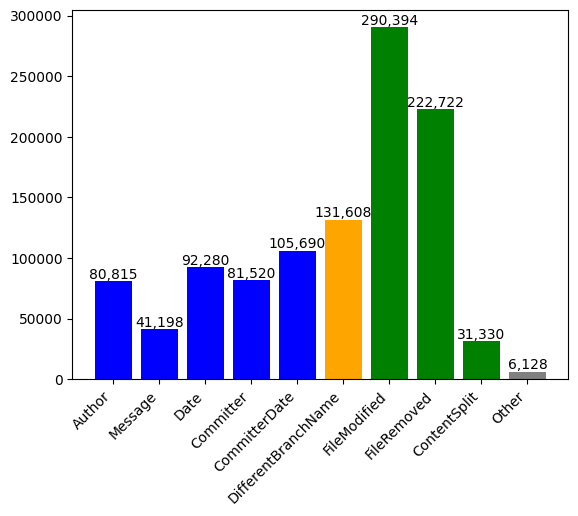

Counter({'ContentModified': 290394,
         'ContentRemoved': 222722,
         'DifferentBranchName': 131608,
         'CommitterDate': 105690,
         'Date': 92280,
         'Committer': 81520,
         'Author': 80815,
         'Message': 41198,
         'ContentDiluted': 31330,
         '': 6128})

In [6]:
display_single(single)
single

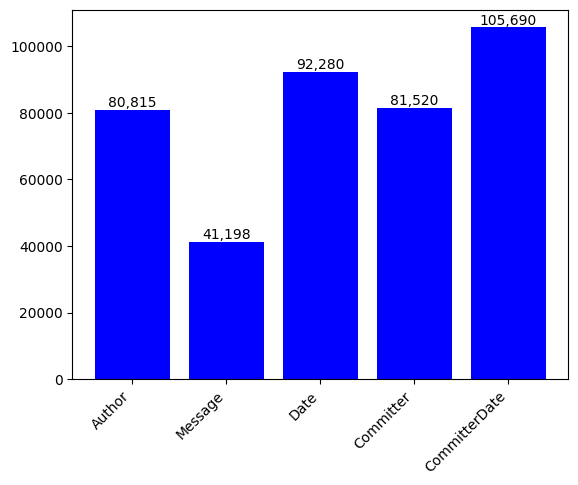

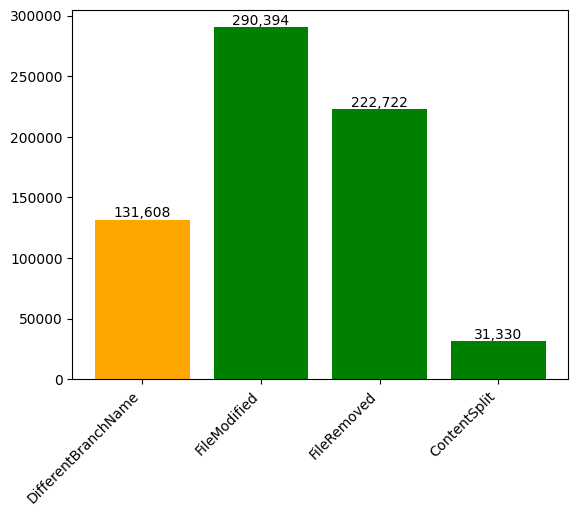

In [7]:
display_single_META(single)
display_single_DIR(single)

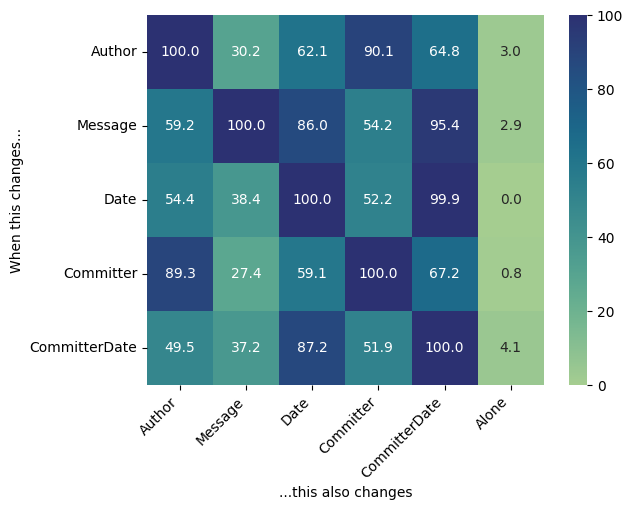

[np.float64(58.72946288391949),
 np.float64(38.859480453114934),
 np.float64(65.73658096775347),
 np.float64(58.060801913780644),
 np.float64(71.22052826782975),
 np.float64(1.7991816851086868)]

In [8]:
hc = heatmap_couple(couple, alone, single, True)
means = [0]*6
for x in range(len(hc)):
    for y in range(len(hc[x])):
        means[y] += hc[x][y]
[x/6 for x in means]

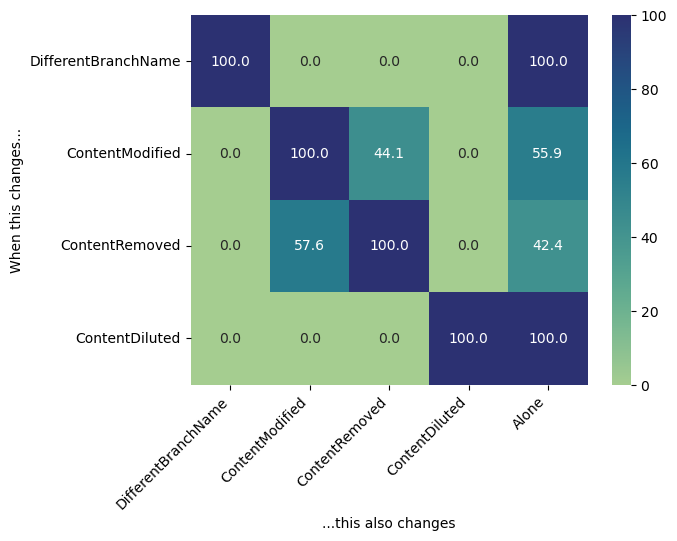

[20.0, 31.512378660392777, 28.829590143047035, 20.0, 59.65803119656018]

In [9]:
hc = heatmap_couple_dir(couple, alone, single, True)
means = [0]*5
for x in range(len(hc)):
    for y in range(len(hc[x])):
        means[y] += hc[x][y]
[x/5 for x in means]

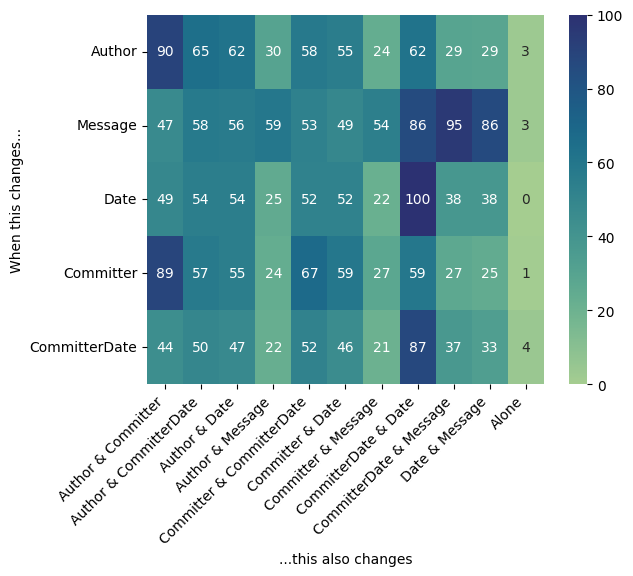

In [9]:
ht = heatmap_triple(triple, couple, single, alone, True)

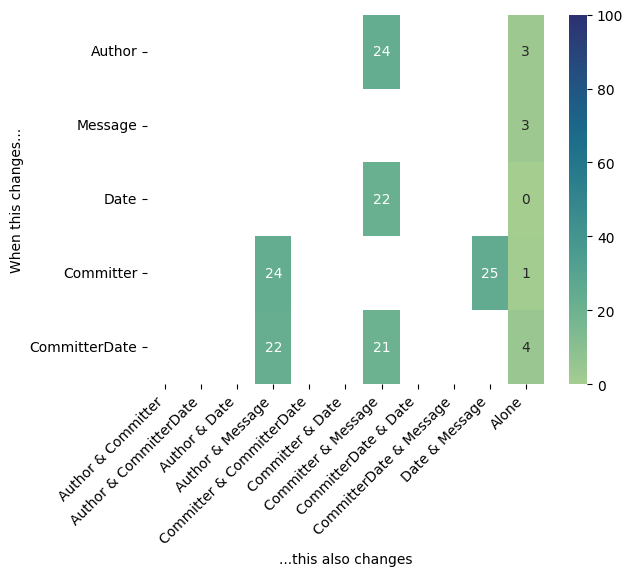

In [10]:
ht = heatmap_triple(triple, couple, single, alone, display=False)
display_triple(ht, filter_percent(ht, 0, 25), with_mask_couple=False)

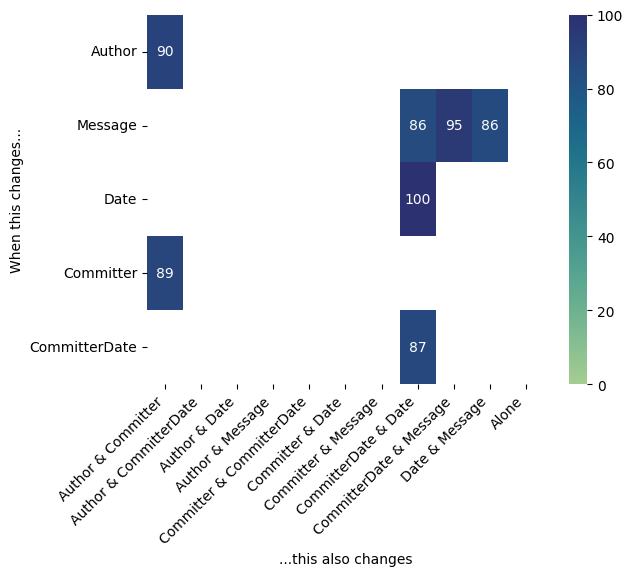

In [12]:
ht = heatmap_triple(triple, couple, single, alone, display=False)
display_triple(ht, filter_percent(ht, 75, 100), with_mask_couple=False)

In [ ]:
df